# GOES Clear Sky Mask Versus HRRR Total Cloud Cover

Download the GOES-19 ABI full-disk Clear Sky Mask scan nearest the selected UTC time and HRRR forecast-hour-zero total cloud cover for the same time. The final cell displays one satellite classification map and one HRRR cloud-cover map.

In [1]:
from datetime import datetime, timezone
from pathlib import Path
import os
import re
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import requests
import xarray as xr
from herbie import Herbie

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cfeature

repo_tmp = Path("tmp").resolve()
data_dir = Path("data").resolve()
(repo_tmp / "matplotlib").mkdir(parents=True, exist_ok=True)
(repo_tmp / "herbie-config").mkdir(parents=True, exist_ok=True)
(repo_tmp / "cache").mkdir(parents=True, exist_ok=True)
data_dir.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(repo_tmp / "matplotlib"))
os.environ.setdefault("HERBIE_CONFIG_PATH", str(repo_tmp / "herbie-config"))
os.environ.setdefault("XDG_CACHE_HOME", str(repo_tmp / "cache"))

 ╭─▌▌Herbie─────────────────────────────────────────────╮
 │ INFO: Created a default config file.                 │
 │ You may view/edit Herbie's configuration here:       │
 │       /home/dmmsp/.config/herbie/config.toml         │
 ╰──────────────────────────────────────────────────────╯



'/home/dmmsp/Projects/observations-vs-forecasts/tmp/cache'

In [2]:
# Same valid time as weatherStationsObservations.ipynb.
valid_time_utc = datetime(2026, 6, 2, 18, 0, tzinfo=timezone.utc)

# GOES-19 is GOES-East for this date.
goes_satellite = "goes19"
goes_product = "ABI-L2-ACMF"

# CONUS plotting bounds: west, east, south, north.
map_extent = [-125.0, -66.5, 24.0, 50.0]

# Downsampling only affects display speed, not the underlying downloaded products.
goes_plot_stride = 8
hrrr_plot_stride = 5

In [3]:
def parse_goes_start_time(key):
    """Parse the GOES filename scan-start timestamp as a UTC datetime."""
    match = re.search(r"_s(\d{4})(\d{3})(\d{2})(\d{2})(\d{2})", key)
    if not match:
        raise ValueError(f"Could not parse GOES start time from {key}")
    year, day_of_year, hour, minute, second = map(int, match.groups())
    return datetime.strptime(
        f"{year} {day_of_year:03d} {hour:02d} {minute:02d} {second:02d}",
        "%Y %j %H %M %S",
    ).replace(tzinfo=timezone.utc)


def list_goes_keys(valid_time, satellite=goes_satellite, product=goes_product):
    """List GOES product files in the target UTC hour from NOAA's public S3 bucket."""
    day_of_year = valid_time.timetuple().tm_yday
    prefix = f"{product}/{valid_time.year}/{day_of_year:03d}/{valid_time.hour:02d}/"
    bucket_url = f"https://noaa-{satellite}.s3.amazonaws.com/"

    response = requests.get(
        bucket_url,
        params={"list-type": "2", "prefix": prefix, "max-keys": "100"},
        timeout=60,
    )
    response.raise_for_status()

    root = ET.fromstring(response.content)
    namespace = {"s3": "http://s3.amazonaws.com/doc/2006-03-01/"}
    return [node.text for node in root.findall(".//s3:Key", namespace)]


def download_nearest_goes_clear_sky_mask(valid_time):
    """Download the GOES Clear Sky Mask scan nearest valid_time."""
    keys = list_goes_keys(valid_time)
    if not keys:
        raise FileNotFoundError(f"No {goes_product} files found for {valid_time:%Y-%m-%d %H UTC}")

    key = min(
        keys,
        key=lambda item: abs((parse_goes_start_time(item) - valid_time).total_seconds()),
    )
    scan_start = parse_goes_start_time(key)
    output_path = data_dir / goes_satellite / Path(key).name
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if not output_path.exists():
        url = f"https://noaa-{goes_satellite}.s3.amazonaws.com/{key}"
        with requests.get(url, stream=True, timeout=180) as response:
            response.raise_for_status()
            with output_path.open("wb") as output:
                for chunk in response.iter_content(chunk_size=1024 * 1024):
                    output.write(chunk)

    return output_path, scan_start


goes_path, goes_scan_start = download_nearest_goes_clear_sky_mask(valid_time_utc)
print(f"GOES file: {goes_path.name}")
print(f"GOES scan start: {goes_scan_start:%Y-%m-%d %H:%M:%S UTC}")

GOES file: OR_ABI-L2-ACMF-M6_G19_s20261531800210_e20261531809518_c20261531810551.nc
GOES scan start: 2026-06-02 18:00:21 UTC


In [4]:
goes_source = xr.open_dataset(goes_path)
projection_attrs = goes_source["goes_imager_projection"].attrs

goes_mask = goes_source["ACM"].isel(
    y=slice(None, None, goes_plot_stride),
    x=slice(None, None, goes_plot_stride),
).load()
goes_x_m = (
    goes_source["x"].isel(x=slice(None, None, goes_plot_stride))
    * projection_attrs["perspective_point_height"]
).load()
goes_y_m = (
    goes_source["y"].isel(y=slice(None, None, goes_plot_stride))
    * projection_attrs["perspective_point_height"]
).load()

goes_projection = ccrs.Geostationary(
    central_longitude=projection_attrs["longitude_of_projection_origin"],
    satellite_height=projection_attrs["perspective_point_height"],
    sweep_axis=projection_attrs["sweep_angle_axis"],
)

goes_flag_values = goes_source["ACM"].attrs["flag_values"].astype(int).tolist()
goes_flag_meanings = goes_source["ACM"].attrs["flag_meanings"].split()
goes_source.close()

print(dict(zip(goes_flag_values, goes_flag_meanings)))
goes_mask

{0: 'clear', 1: 'probably_clear', 2: 'probably_cloudy', 3: 'cloudy'}


<xarray.DataArray 'ACM' (y: 678, x: 678)> Size: 2MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(678, 678), dtype=float32)
Coordinates:
  * y                                (y) float32 3kB 0.1518 0.1514 ... -0.1515
  * x                                (x) float32 3kB -0.1518 -0.1514 ... 0.1515
    t                                datetime64[ns] 8B 2026-06-02T18:05:06.44...
    y_image                          float32 4B 0.0
    x_image                          float32 4B 0.0
    retrieval_local_zenith_angle     float32 4B 90.0
    quantitative_local_zenith_angle  float32 4B 70.0
    retrieval_solar_zenith_angle     float32 4B 180.0
Attributes:
    long_name:      (Real-Value) four level cloud mask
    flag_values:    [0 1 2 3]
    flag_meanings:  clear probably_clear probably_cloudy cloudy
    grid_mapping:   goes_imager_projection

In [5]:
def download_hrrr_total_cloud_cover(valid_time):
    """Download HRRR f00 entire-atmosphere total cloud cover."""
    run_time = pd.Timestamp(valid_time).tz_convert("UTC").tz_localize(None).to_pydatetime()
    hrrr = Herbie(run_time, model="hrrr", product="sfc", fxx=0, save_dir=data_dir)
    subset_path = hrrr.download(":TCDC:entire atmosphere:", verbose=False)
    if isinstance(subset_path, (list, tuple)):
        subset_path = subset_path[0]

    ds = xr.open_dataset(
        subset_path,
        engine="cfgrib",
        backend_kwargs={"indexpath": ""},
    )
    if "tcc" not in ds:
        raise KeyError(f"Expected HRRR variable 'tcc', found {list(ds.data_vars)}")

    cloud_cover = ds["tcc"].squeeze().load()
    latitude = ds["latitude"].load()
    longitude = (((ds["longitude"] + 180.0) % 360.0) - 180.0).load()
    ds.close()

    # cfgrib may expose percentages as 0..100 or fractions as 0..1.
    if float(cloud_cover.max()) <= 1.0:
        cloud_cover = cloud_cover * 100.0

    return xr.Dataset(
        data_vars={"total_cloud_cover_percent": cloud_cover},
        coords={"latitude": latitude, "longitude": longitude},
        attrs={
            "model": "HRRR",
            "forecast_hour": 0,
            "valid_time_utc": pd.Timestamp(valid_time).isoformat(),
            "grib_subset_path": str(subset_path),
        },
    )


hrrr_cloud = download_hrrr_total_cloud_cover(valid_time_utc)
hrrr_cloud

✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2026-Jun-02 18:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local


<xarray.Dataset> Size: 38MB
Dimensions:                    (y: 1059, x: 1799)
Coordinates:
    latitude                   (y, x) float64 15MB 21.14 21.15 ... 47.85 47.84
    longitude                  (y, x) float64 15MB -122.7 -122.7 ... -60.92
    time                       datetime64[ns] 8B 2026-06-02T18:00:00
    step                       timedelta64[ns] 8B 00:00:00
    atmosphere                 float64 8B 0.0
    valid_time                 datetime64[ns] 8B 2026-06-02T18:00:00
Dimensions without coordinates: y, x
Data variables:
    total_cloud_cover_percent  (y, x) float32 8MB 61.0 60.0 100.0 ... 8.0 9.0
Attributes:
    model:             HRRR
    forecast_hour:     0
    valid_time_utc:    2026-06-02T18:00:00+00:00
    grib_subset_path:  /home/dmmsp/Projects/observations-vs-forecasts/data/hr...

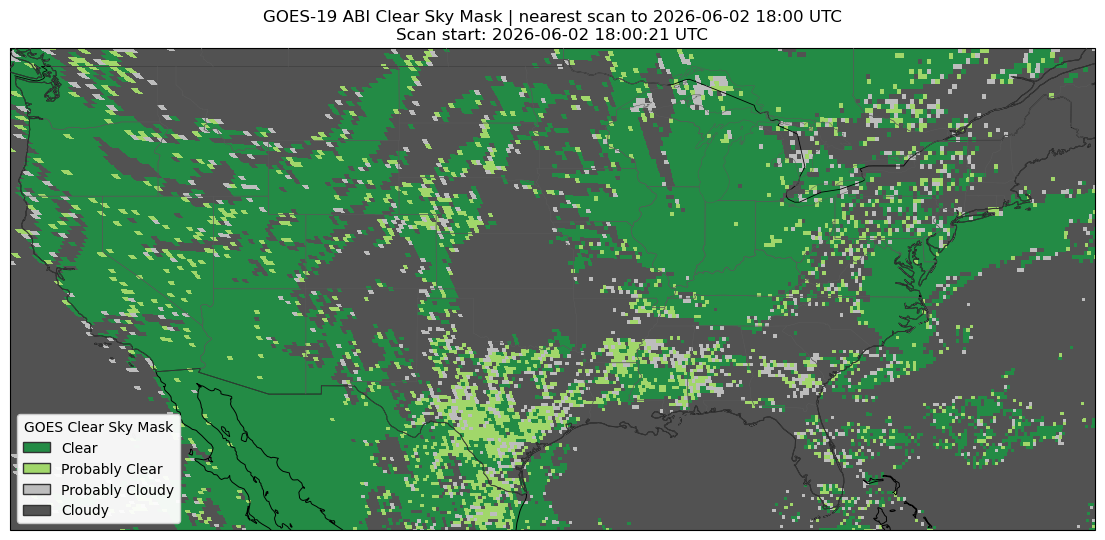

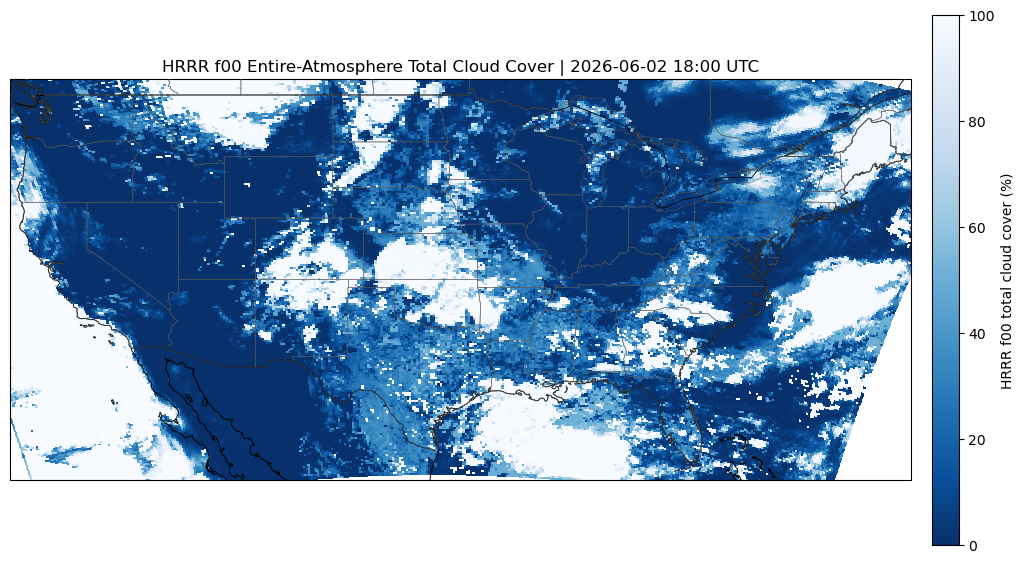

In [6]:
def add_map_features(ax):
    ax.set_extent(map_extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, zorder=3)
    ax.add_feature(cfeature.STATES, linewidth=0.35, edgecolor="0.35", zorder=3)


valid_label = pd.Timestamp(valid_time_utc).strftime("%Y-%m-%d %H:%M UTC")

# GOES Clear Sky Mask categories.
goes_colors = ["#238b45", "#a1d76a", "#bdbdbd", "#525252"]
goes_cmap = ListedColormap(goes_colors)
goes_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], goes_cmap.N)

fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
add_map_features(ax)
ax.pcolormesh(
    goes_x_m,
    goes_y_m,
    goes_mask,
    transform=goes_projection,
    shading="auto",
    cmap=goes_cmap,
    norm=goes_norm,
    zorder=1,
)
legend_labels = [meaning.replace("_", " ").title() for meaning in goes_flag_meanings]
ax.legend(
    handles=[
        Patch(facecolor=color, edgecolor="0.2", label=label)
        for color, label in zip(goes_colors, legend_labels)
    ],
    loc="lower left",
    framealpha=0.95,
    title="GOES Clear Sky Mask",
)
ax.set_title(
    f"GOES-19 ABI Clear Sky Mask | nearest scan to {valid_label}\n"
    f"Scan start: {goes_scan_start:%Y-%m-%d %H:%M:%S UTC}"
)
plt.show()


# HRRR f00 entire-atmosphere total cloud cover.
hrrr_plot = hrrr_cloud.isel(
    y=slice(None, None, hrrr_plot_stride),
    x=slice(None, None, hrrr_plot_stride),
)

fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
add_map_features(ax)
mesh = ax.pcolormesh(
    hrrr_plot["longitude"],
    hrrr_plot["latitude"],
    hrrr_plot["total_cloud_cover_percent"],
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="Blues_r",
    vmin=0,
    vmax=100,
    zorder=1,
)
colorbar = plt.colorbar(mesh, ax=ax, orientation="vertical", pad=0.02, shrink=0.86)
colorbar.set_label("HRRR f00 total cloud cover (%)")
ax.set_title(f"HRRR f00 Entire-Atmosphere Total Cloud Cover | {valid_label}")
plt.show()